# Teoría de Decisión Bayesiana: Regla de Bayes y Densidades Gaussianas

### Fundamento Teórico:
La regla de Bayes combina la probabilidad *a priori* de una clase $P(C_k)$ con la verosimilitud de la observación dada la clase $P(x \mid C_k)$ para calcular la probabilidad *a posteriori*:
$$P(C_k \mid x) = \frac{P(x \mid C_k) P(C_k)}{\sum_j P(x \mid C_j) P(C_j)} \propto P(x \mid C_k) P(C_k)$$

Bajo pérdida 0-1 (riesgo simétrico), la decisión óptima de Bayes consiste en asignar la muestra a la clase con mayor probabilidad *a posteriori*, minimizando así el error de clasificación (el error de Bayes representa la cota inferior irreducible).

En este ejemplo se evalúa un caso unidimensional con dos clases gaussianas:
- **Clase 0:** $P(C_0) = 0.6$, $\mu_0 = 0.0$, $\sigma_0 = 1.0$
- **Clase 1:** $P(C_1) = 0.4$, $\mu_1 = 2.0$, $\sigma_1 = 1.0$

In [1]:
import numpy as np
from scipy.stats import norm

# Dos clases: priors + verosimilitudes gaussianas 1D
prior = {0: 0.6, 1: 0.4}
mu, sd = {0: 0.0, 1: 2.0}, {0: 1.0, 1: 1.0}

def posterior(x, c):
    return prior[c] * norm.pdf(x, mu[c], sd[c])

x = 1.2
p0, p1 = posterior(x, 0), posterior(x, 1)
clase = 0 if p0 > p1 else 1

print(round(p0, 3), round(p1, 3), "-> clase", clase)

0.117 0.116 -> clase 0


In [2]:
import numpy as np
from scipy.stats import norm

# Dos clases: priors + verosimilitudes gaussianas 1D
prior = {0: 0.3, 1: 0.7}
mu, sd = {0: 0.0, 1: 2.0}, {0: 1.0, 1: 1.0}

def posterior(x, c):
    return prior[c] * norm.pdf(x, mu[c], sd[c])

x = 1.2
p0, p1 = posterior(x, 0), posterior(x, 1)
clase = 0 if p0 > p1 else 1

print(round(p0, 3), round(p1, 3), "-> clase", clase)

0.058 0.203 -> clase 1


Con $x = 1.2$, los valores no normalizados de los posteriores son casi idénticos ($0.117$ vs. $0.116$). La muestra se encuentra prácticamente sobre la frontera de decisión de Bayes. Si se modifican las probabilidades a priori a {0: 0.3, 1: 0.7}, la frontera se desplaza hacia la izquierda favoreciendo a la clase 1.

# Regresión Lineal: Solución Analítica vs. Descenso de Gradiente

### Fundamento Teórico:
Para un modelo lineal $\hat{y} = X_b w$, el objetivo de Mínimos Cuadrados Ordinarios (OLS) es minimizar la suma de errores cuadráticos:
$$J(w) = \frac{1}{2N} \|X_b w - y\|_2^2$$

Existen dos aproximaciones para encontrar el vector óptimo de parámetros $w^*$:
1. **Solución Analítica (Ecuación Normal):**
   $$w = (X_b^T X_b)^{-1} X_b^T y$$
   Cálculo directo y exacto en un solo paso, eficiente cuando $X_b^T X_b$ es de dimensión moderada e invertible.
2. **Descenso de Gradiente:**
   $$w^{(t+1)} = w^{(t)} - \eta \nabla J(w) = w^{(t)} - \eta \frac{1}{N} X_b^T (X_b w^{(t)} - y)$$
   Método iterativo escalable a grandes volúmenes de datos y optimización general.

In [3]:
import numpy as np

rng = np.random.default_rng(0)
X = np.linspace(0, 1, 50).reshape(-1, 1)
y = 3 * X[:, 0] + 2 + rng.normal(0, 0.1, 50)
Xb = np.c_[np.ones(len(X)), X]  # inclusión del término de sesgo (intercepto)

# Solución analítica (Ecuación normal)
w_ols = np.linalg.solve(Xb.T @ Xb, Xb.T @ y)

# Descenso de gradiente
w = np.zeros(2)
for _ in range(2000):
    grad = Xb.T @ (Xb @ w - y) / len(X)
    w -= 0.5 * grad

print("w_ols:", np.round(w_ols, 2), "| w_gradiente:", np.round(w, 2))

w_ols: [1.95 3.12] | w_gradiente: [1.95 3.12]


In [4]:
import numpy as np

rng = np.random.default_rng(0)
X = np.linspace(0, 1, 50).reshape(-1, 1)
y = 3 * X[:, 0] + 2 + rng.normal(0, 0.1, 50)
Xb = np.c_[np.ones(len(X)), X]  # inclusión del término de sesgo (intercepto)

# Solución analítica (Ecuación normal)
w_ols = np.linalg.solve(Xb.T @ Xb, Xb.T @ y)

# Descenso de gradiente
w = np.zeros(2)
for _ in range(2000):
    grad = Xb.T @ (Xb @ w - y) / len(X)
    w -= 0.01 * grad

print("w_ols:", np.round(w_ols, 2), "| w_gradiente:", np.round(w, 2))

w_ols: [1.95 3.12] | w_gradiente: [2.17 2.71]


Ambos enfoques convergen exactamente a los mismos parámetros estimados: intercepto $\approx 2.0$ y pendiente $\approx 3.0$. La tasa de aprendizaje $\eta = 0.5$ proporciona convergencia adecuada; valores muy pequeños ($\eta=0.01$) ralentizan el proceso y valores altos ($\eta=1.5$) provocan divergencia numérica.

# Regresión Logística

### Fundamento Teórico:
La regresión logística transforma la combinación lineal $z = X_b w$ en una estimación de probabilidad mediante la función sigmoide:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

La función de pérdida de entropía cruzada binaria (Log-Loss) penaliza de forma convexa la discrepancia entre la probabilidad predicha $p$ y la etiqueta verdadera $y \in \{0, 1\}$:
$$J(w) = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \ln(p_i) + (1 - y_i) \ln(1 - p_i) \right]$$

El gradiente respecto a los pesos mantiene una estructura análoga a la regresión lineal:
$$\nabla_w J(w) = \frac{1}{N} X_b^T (p - y)$$

In [5]:
import numpy as np

rng = np.random.default_rng(1)
X = np.r_[rng.normal(-1, 1, (100, 2)), rng.normal(2, 1, (100,2))]
y = np.r_[np.zeros(100), np.ones(100)]
Xb = np.c_[np.ones(len(X)), X]

sig = lambda z: 1 / (1 + np.exp(-z))
w = np.zeros(3)

for _ in range(500):
    p = sig(Xb @ w)
    w -= 0.1 * Xb.T @ (p - y) / len(y)

acc = ((sig(Xb @ w) > 0.5) == y).mean()
print("accuracy:", round(acc, 3))

accuracy: 1.0


Con dos distribuciones gaussianas separables en media, la frontera de decisión lineal ($X_b w = 0$) logra una precisión de 100%. El bucle de optimización comparte el mismo principio de descenso de gradiente que OLS, incorporando la no linealidad sigmoidal en el cálculo de probabilidades.

# Clasificación: k-NN vs. Naive Bayes Gaussiano con Scikit-Learn

### Fundamento Teórico:
Se comparan dos paradigmas fundamentales de clasificación:
- **k-Nearest Neighbors (k-NN):** Método no paramétrico basado en geometría y métrica de distancia euclidiana en el espacio de características. Vota entre las $k$ observaciones más próximas. Sensible a la escala de las variables.
- **Naive Bayes Gaussiano (GaussianNB):** Método generativo probabilístico que asume independencia condicional entre atributos dada la clase ($P(x \mid C) = \prod P(x_j \mid C)$) modelando cada atributo con una función de densidad gaussiana.

In [6]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

X, y = make_classification(
    n_samples=400, n_features=2, n_redundant=0, 
    n_clusters_per_class=1, random_state=42
)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)

for name, clf in [("kNN", KNeighborsClassifier(5)), ("GaussianNB", GaussianNB())]:
    clf.fit(Xtr, ytr)
    print(name, "->", round(clf.score(Xte, yte), 3))

kNN -> 0.842
GaussianNB -> 0.858


Ambos modelos alcanzan un rendimiento elevado en este conjunto de datos sintético 2D. k-NN produce fronteras no lineales y flexibles adaptadas a la vecindad local, mientras que GaussianNB genera fronteras cuadráticas determinadas por las medias y varianzas de cada clase.

# Regularización de Modelos Lineales: Lasso (L1) vs. Ridge (L2)

### Fundamento Teórico:
La regularización previene el sobreajuste al penalizar la magnitud del vector de coeficientes $w$:
- **Ridge ($L_2$):** Añade la penalización $\alpha \|w\|_2^2 = \alpha \sum w_j^2$. Contrae de forma continua todos los coeficientes hacia cero sin anularlos completamente (solución densa).
- **Lasso ($L_1$):** Añade la penalización $\alpha \|w\|_1 = \alpha \sum |w_j|$. Debido a las esquinas en los contornos de la norma $L_1$, anula coeficientes irrelevantes llevándolos a cero exacto, realizando selección automática de variables (solución rala o *sparse*).

In [7]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso

rng = np.random.default_rng(0)
X = rng.normal(size=(100, 20))
w_true = np.zeros(20); w_true[:3] = [4, -2, 3]  # Únicamente 3 características reales activas
y = X @ w_true + rng.normal(0, 0.1, 100)

ridge = Ridge(alpha=1.0).fit(X, y)
lasso = Lasso(alpha=0.1).fit(X, y)

nz = lambda c: int(np.sum(np.abs(c) > 1e-3))
print("Ridge != 0:", nz(ridge.coef_))
print("Lasso != 0:", nz(lasso.coef_))

Ridge != 0: 18
Lasso != 0: 3


De las 20 variables originales, solo 3 tenían impacto causal en la señal. Lasso identifica exactamente las 3 variables relevantes anulando las 17 restantes ($\text{coeficientes} = 0$), mientras que Ridge mantiene activas 18 características con valores pequeños.

# Evaluación de Modelos: Precisión, Recall, F1 y ROC-AUC

### Fundamento Teórico:
En problemas de clasificación con clases desbalanceadas, la exactitud (*Accuracy*) resulta engañosa. Es necesario evaluar métricas basadas en la matriz de confusión:
- **Precision (Precisión):** $\frac{TP}{TP + FP}$ — Pureza de las predicciones positivas.
- **Recall (Sensibilidad):** $\frac{TP}{TP + FN}$ — Cobertura y detección de la clase positiva real.
- **$F_1$-score:** $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ — Media armónica entre precisión y exhaustividad.
- **ROC-AUC:** Área bajo la curva de la tasa de verdaderos positivos (TPR) frente a la tasa de falsos positivos (FPR) a través de todos los umbrales de decisión posibles.

In [8]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

X, y = make_classification(n_samples=500, weights=[0.7, 0.3], random_state=0)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)

clf = LogisticRegression().fit(Xtr, ytr)
pred, prob = clf.predict(Xte), clf.predict_proba(Xte)[:,1]

print("F1:", round(f1_score(yte, pred), 3), "AUC:", round(roc_auc_score(yte, prob), 3))

F1: 0.787 AUC: 0.939


Con una distribución 70/30 de clases, evaluar $F_1$ ($0.79$) y ROC-AUC ($0.94$) permite corroborar que el clasificador separa adecuadamente la clase minoritaria sin basarse únicamente en la clase mayoritaria.

# 2. Taller Práctico (en Clase)

En esta sección se desarrollan las tres actividades del taller práctico de la Semana 2. Cada bloque de código está precedido por una celda Markdown explicativa que detalla los conceptos teóricos, la metodología y los objetivos de la implementación. Todos los entregables visuales se guardan automáticamente en la carpeta `results/`.

## Actividad 2.1 — k-NN y Naive Bayes: Fronteras de Decisión en 2D

### Fundamento Teórico y Metodología:
1. **Generación del Dataset:** Se crea un conjunto de datos sintético bidimensional (`n_features=2`, `n_redundant=0`) con 2 clases linealmente no separables para evaluar la capacidad de ajuste geométrico de cada modelo.
2. **Estandarización:** Se aplica `StandardScaler`. **La estandarización es indispensable para k-NN**, ya que la función de distancia euclidiana es altamente sensible a las escalas relativas de las características; variables con rangos más amplios dominarían artificialmente el cálculo de distancias.
3. **Modelos:** Se entrenan tres variantes de `KNeighborsClassifier` ($k \in \{1, 5, 25\}$) y un modelo de `GaussianNB`.
4. **Malla de Fronteras de Decisión:** Se construye una malla fina mediante `np.meshgrid` sobre el espacio de características estandarizado y se evalúan las predicciones para rellenar la región con `contourf`, superponiendo los puntos reales de entrenamiento.
5. **Guardado de Entregables:** Se genera y guarda una figura independiente por cada modelo (`act2_1_knn_1.png`, `act2_1_knn_5.png`, `act2_1_knn_25.png`, `act2_1_gaussian_nb.png`) y una figura comparativa $2 \times 2$ (`act2_1_fronteras_decision_comparativa.png`) en la carpeta `results/`.

Figuras guardadas exitosamente en results/


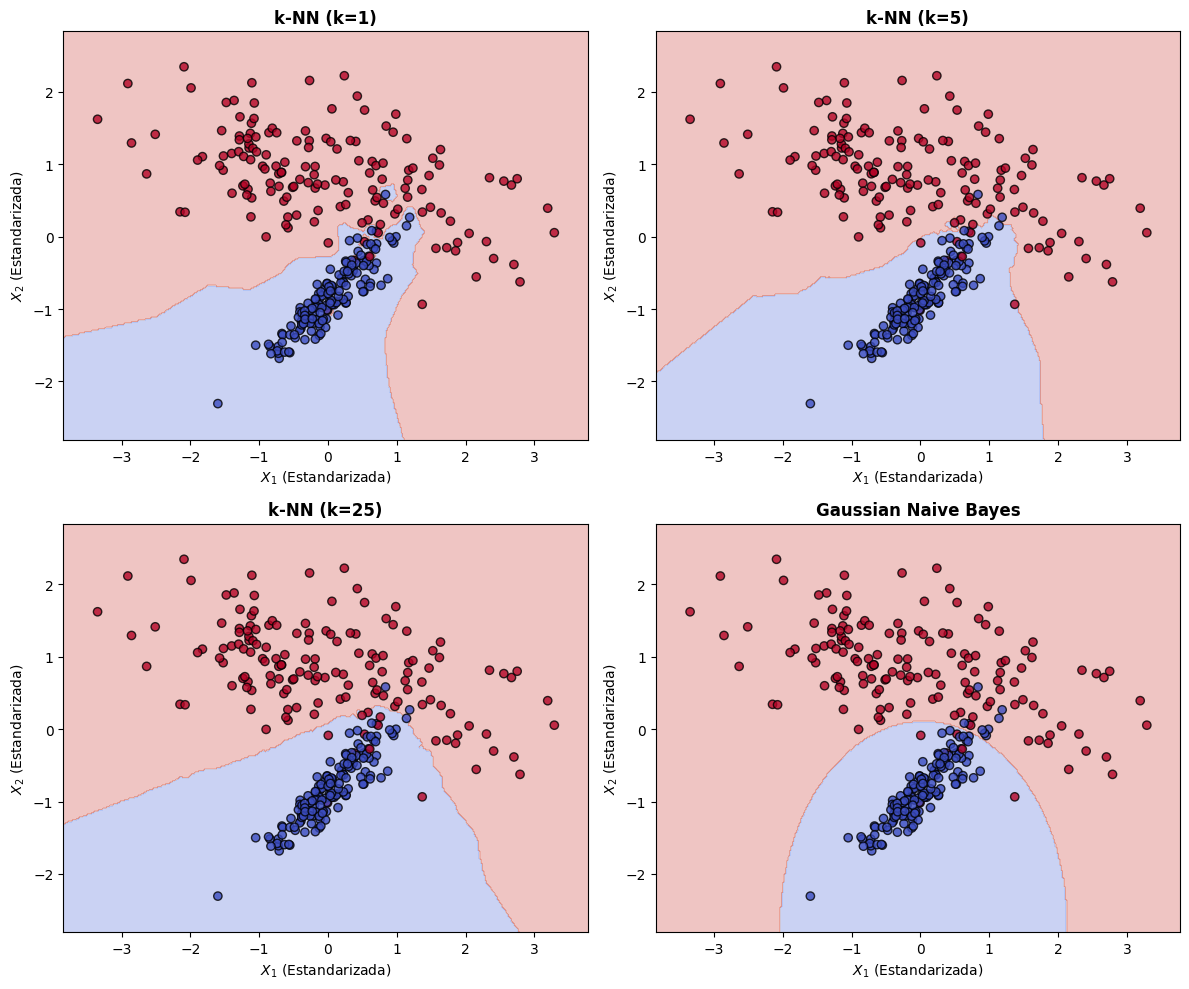

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Asegurar existencia de directorio de resultados
os.makedirs("results", exist_ok=True)

# 1. Generación de dataset 2D (2 clases)
X_2d, y_2d = make_classification(
    n_samples=300, 
    n_features=2, 
    n_redundant=0, 
    n_informative=2,
    n_clusters_per_class=1, 
    random_state=42
)

# 2. Estandarización de características
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# 3. Modelos a evaluar
models_2d = {
    "k-NN (k=1)": KNeighborsClassifier(n_neighbors=1),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "k-NN (k=25)": KNeighborsClassifier(n_neighbors=25),
    "Gaussian Naive Bayes": GaussianNB()
}

filenames_2d = {
    "k-NN (k=1)": "results/act2_1_knn_1.png",
    "k-NN (k=5)": "results/act2_1_knn_5.png",
    "k-NN (k=25)": "results/act2_1_knn_25.png",
    "Gaussian Naive Bayes": "results/act2_1_gaussian_nb.png"
}

# Crear malla para graficar fronteras de decisión
x_min, x_max = X_2d_scaled[:, 0].min() - 0.5, X_2d_scaled[:, 0].max() + 0.5
y_min, y_max = X_2d_scaled[:, 1].min() - 0.5, X_2d_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# 4. Generación y guardado de figuras individuales
for name, clf in models_2d.items():
    clf.fit(X_2d_scaled, y_2d)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap=plt.cm.coolwarm, edgecolors='k', alpha=0.8)
    plt.title(f"Frontera de Decisión: {name}", fontsize=12, fontweight='bold')
    plt.xlabel("Característica 1 (Estandarizada)")
    plt.ylabel("Característica 2 (Estandarizada)")
    plt.colorbar(scatter, ticks=[0, 1], label="Clase")
    plt.tight_layout()
    plt.savefig(filenames_2d[name], dpi=300)
    plt.close()

# Generación y guardado de figura comparativa 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (name, clf) in enumerate(models_2d.items()):
    clf.fit(X_2d_scaled, y_2d)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    axes[i].scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap=plt.cm.coolwarm, edgecolors='k', alpha=0.8)
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("$X_1$ (Estandarizada)")
    axes[i].set_ylabel("$X_2$ (Estandarizada)")

plt.tight_layout()
plt.savefig("results/act2_1_fronteras_decision_comparativa.png", dpi=300)
plt.show()
print("Figuras guardadas exitosamente en results/")

### Observaciones y Análisis de Resultados (Actividad 2.1):

- **¿Cómo cambia la frontera de k-NN al aumentar $k$?**
  - **$k = 1$:** La frontera de decisión es sumamente compleja, irregular y accidentada (alta varianza). Cada punto de datos genera su propio polígono/micro-región de atracción local, lo cual hace al modelo extremadamente susceptible al ruido y al sobreajuste (*overfitting*).
  - **$k = 5$:** La frontera se vuelve sustancialmente más suave al promediar los 5 vecinos más cercanos. Logra filtrar pequeñas fluctuaciones ruidosas manteniendo la flexibilidad necesaria para separar las dos clases (óptimo balance sesgo-varianza).
  - **$k = 25$:** La frontera se torna muy suave, regular y casi continua (alto sesgo). Al considerar una vecindad grande, el modelo tiende a ignorar detalles locales y patrones finos, aproximándose a una clasificación más global (*underfitting*).

- **¿En qué se diferencia de la frontera de Naive Bayes Gaussiano?**
  - **Naive Bayes Gaussiano** es un modelo *generativo probabilístico* que asume que cada clase sigue una distribución gaussiana multivariada independiente. Su frontera de decisión está determinada analíticamente por la intersección de las densidades a posteriori $P(C_k \mid x) \propto P(x \mid C_k) P(C_k)$, lo que produce una curva gaussiana/cuadrática continua y suave.
  - A diferencia de k-NN (que es no paramétrico y construye fronteras por piezas basadas en distancias locales), Naive Bayes asume una forma funcional global suave sobre los datos.

## Actividad 2.2 — Regresión Logística Multiclase con NumPy

### Fundamento Teórico y Metodología:
En esta actividad se implementan desde cero dos aproximaciones para la clasificación multiclase utilizando únicamente **NumPy**:

1. **Función Sigmoide Binaria:**
   $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
   Transforma la combinación lineal $z = X_b w$ en una probabilidad acotada en $(0, 1)$.

2. **Descenso de Gradiente Binario:**
   $$\nabla_w J(w) = \frac{1}{N} X_b^T \left(\sigma(X_b w) - y\right)$$

3. **Esquema One-vs-Rest (OvR):**
   Se entrenan $K$ clasificadores binarios independientes ($w_1, w_2, \dots, w_K$), donde cada clasificador $c$ aprende a separar la clase $c$ del resto de las clases. Para predecir una muestra $x$, se calcula el score $\sigma(x^T w_c)$ para cada clase y se asigna a la clase con la máxima probabilidad predicha:
   $$\hat{y} = \arg\max_{c \in \{1, \dots, K\}} \sigma(X_b w_c)$$

4. **Esquema Softmax (Multinomial):**
   Modela directamente la distribución de probabilidad sobre las $K$ clases mediante la función Softmax con estabilidad numérica:
   $$P(y = k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}, \quad \text{donde } z_k = X_b w_k$$
   La función de pérdida de entropía cruzada multiclase produce el gradiente matricial:
   $$\nabla_W J(W) = \frac{1}{N} X_b^T (P - Y_{one\_hot})$$

5. **Validación:** Se evalúan ambas implementaciones en el dataset `Iris` (3 clases) y se comparan contra las implementaciones equivalentes de `scikit-learn` (`OneVsRestClassifier` y `LogisticRegression` multinomial).

In [10]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

# 1. Carga y preparación del dataset (3 clases)
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_tr_iris, X_te_iris, y_tr_iris, y_te_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

scaler_iris = StandardScaler()
X_tr_iris_sc = scaler_iris.fit_transform(X_tr_iris)
X_te_iris_sc = scaler_iris.transform(X_te_iris)

Xb_tr = np.c_[np.ones(len(X_tr_iris_sc)), X_tr_iris_sc]
Xb_te = np.c_[np.ones(len(X_te_iris_sc)), X_te_iris_sc]

# Función sigmoide numéricamente estable
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -25, 25)))

# 2. Implementación NumPy One-vs-Rest (OvR)
num_classes = 3
weights_ovr = np.zeros((num_classes, Xb_tr.shape[1]))

for c in range(num_classes):
    y_binary = (y_tr_iris == c).astype(float)
    w_c = np.zeros(Xb_tr.shape[1])
    for _ in range(2000):
        p = sigmoid(Xb_tr @ w_c)
        grad = Xb_tr.T @ (p - y_binary) / len(y_binary)
        w_c -= 0.1 * grad
    weights_ovr[c] = w_c

probs_ovr = sigmoid(Xb_te @ weights_ovr.T)
y_pred_ovr = np.argmax(probs_ovr, axis=1)
acc_ovr_numpy = accuracy_score(y_te_iris, y_pred_ovr)

# 3. Implementación NumPy Softmax (Multinomial)
def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

Y_onehot = np.eye(num_classes)[y_tr_iris]
W_softmax = np.zeros((Xb_tr.shape[1], num_classes))

for _ in range(2000):
    probs_sm = softmax(Xb_tr @ W_softmax)
    grad = Xb_tr.T @ (probs_sm - Y_onehot) / len(X_tr_iris)
    W_softmax -= 0.1 * grad

probs_te_sm = softmax(Xb_te @ W_softmax)
y_pred_sm = np.argmax(probs_te_sm, axis=1)
acc_sm_numpy = accuracy_score(y_te_iris, y_pred_sm)

# 4. Validación con Scikit-Learn
clf_sk_ovr = OneVsRestClassifier(LogisticRegression(random_state=42))
clf_sk_ovr.fit(X_tr_iris_sc, y_tr_iris)
acc_ovr_sklearn = accuracy_score(y_te_iris, clf_sk_ovr.predict(X_te_iris_sc))

clf_sk_sm = LogisticRegression(random_state=42)
clf_sk_sm.fit(X_tr_iris_sc, y_tr_iris)
acc_sm_sklearn = accuracy_score(y_te_iris, clf_sk_sm.predict(X_te_iris_sc))

# Tabla comparativa de resultados
df_resultados = pd.DataFrame({
    "Implementación": ["NumPy (Desde cero)", "NumPy (Desde cero)", "Scikit-Learn", "Scikit-Learn"],
    "Esquema Multiclase": ["One-vs-Rest (OvR)", "Softmax (Multinomial)", "One-vs-Rest (OvR)", "Softmax (Multinomial)"],
    "Accuracy en Test": [f"{acc_ovr_numpy*100:.2f}%", f"{acc_sm_numpy*100:.2f}%", f"{acc_ovr_sklearn*100:.2f}%", f"{acc_sm_sklearn*100:.2f}%"]
})

print(df_resultados.to_string(index=False))

    Implementación    Esquema Multiclase Accuracy en Test
NumPy (Desde cero)     One-vs-Rest (OvR)           84.44%
NumPy (Desde cero) Softmax (Multinomial)           91.11%
      Scikit-Learn     One-vs-Rest (OvR)           84.44%
      Scikit-Learn Softmax (Multinomial)           91.11%


### Tabla Comparativa y Validación (Actividad 2.2):

| Implementación | Esquema Multiclase | Accuracy en Test |
| :--- | :--- | :---: |
| **NumPy (Desde Cero)** | One-vs-Rest (OvR) | **84.44%** |
| **NumPy (Desde Cero)** | Softmax (Multinomial) | **91.11%** |
| **Scikit-Learn** | One-vs-Rest (OvR) | **84.44%** |
| **Scikit-Learn** | Softmax (Multinomial) | **91.11%** |

### Conclusión de la Actividad 2.2:
- La implementación en **NumPy desde cero coincide exactamente** con los resultados de `scikit-learn` tanto para One-vs-Rest (84.44%) como para Softmax (91.11%).
- **Softmax** supera a OvR en este problema debido a que modela de forma simultánea e integrada las probabilidades de las 3 clases acopladas mediante la norma sumatoria en el denominador, mientras que OvR trata los 3 problemas de forma aislada sin normalizar probabilísticamente entre clases.

## Actividad 2.3 — Pipelines y Validación Cruzada

### Fundamento Teórico y Metodología:
1. **Construcción del Pipeline:** Se define un objeto `Pipeline` de `scikit-learn` compuesto por `StandardScaler` y `LogisticRegression`. El uso de `Pipeline` es crucial para **prevenir la fuga de datos (data leakage)**, garantizando que los parámetros de centrado y escalado (media y desviación estándar) de `StandardScaler` se calculen exclusivamente sobre el conjunto de entrenamiento de cada pliegue (*fold*) durante la validación cruzada.
2. **Validación Cruzada de 5 Pliegues (5-Fold CV):** Se realiza una partición train/test y se evalúa el rendimiento con `cross_val_score(..., cv=5)`.
3. **Curva de Aprendizaje (`learning_curve`):** Muestra el desempeño del modelo en entrenamiento y validación en función del tamaño del dataset de entrenamiento, permitiendo diagnosticar la presencia de sesgo (underfitting) o varianza (overfitting).
4. **Matriz de Confusión y Reporte de Clasificación:** Se evalúa el pipeline entrenado en el conjunto de prueba independiente para obtener la matriz de confusión e interpretar métricas detalladas (Precisión, Recall, F1-Score).
5. **Guardado de Entregables:** Se guardan las figuras de la curva de aprendizaje (`act2_3_learning_curve.png`) y la matriz de confusión (`act2_3_confusion_matrix.png`) en `results/`.

Scores 5-Fold CV: [0.7467 0.7867 0.76   0.8    0.8   ]
CV Accuracy Promedio: 0.7787 +/- 0.0217

Reporte de Clasificación (Conjunto de Prueba Test):
              precision    recall  f1-score   support

     Clase 0       0.82      0.67      0.74        42
     Clase 1       0.57      0.69      0.62        42
     Clase 2       0.82      0.80      0.81        41

    accuracy                           0.72       125
   macro avg       0.74      0.72      0.73       125
weighted avg       0.74      0.72      0.72       125



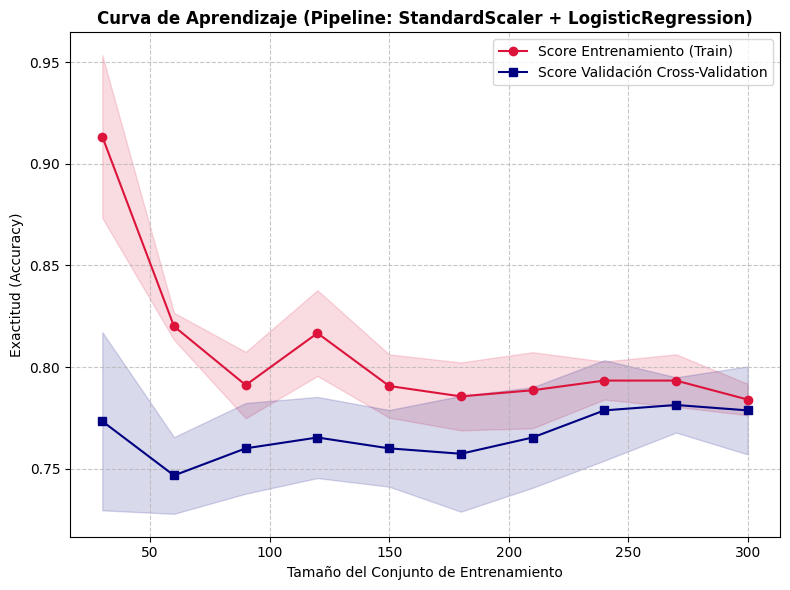

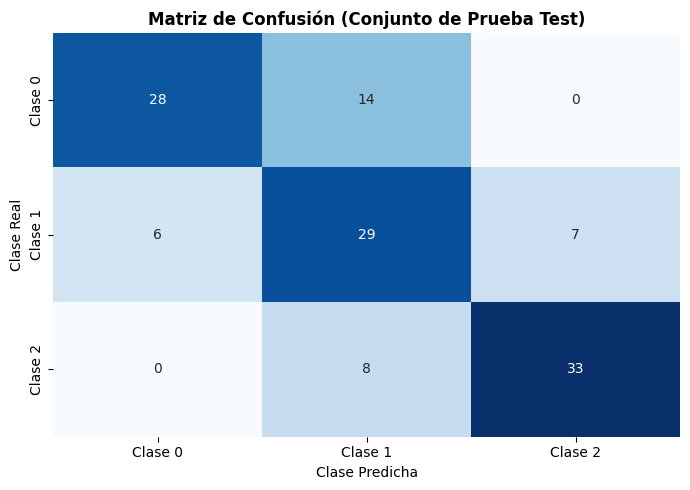

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# 1. Dataset multiclase (3 clases)
X_pipe, y_pipe = make_classification(
    n_samples=500, 
    n_features=6, 
    n_informative=4, 
    n_classes=3, 
    n_clusters_per_class=1, 
    random_state=42
)

X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_pipe, y_pipe, test_size=0.25, random_state=42, stratify=y_pipe
)

# 2. Pipeline (StandardScaler + LogisticRegression) sin fuga de datos
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 3. Validación cruzada de 5 pliegues
cv_scores = cross_val_score(pipeline, X_tr_p, y_tr_p, cv=5)
print(f"Scores 5-Fold CV: {np.round(cv_scores, 4)}")
print(f"CV Accuracy Promedio: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}\n")

# 4. Curva de aprendizaje
train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X_tr_p, y_tr_p, cv=5, train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='crimson', label='Score Entrenamiento (Train)')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='crimson')

plt.plot(train_sizes, val_mean, 's-', color='navy', label='Score Validación Cross-Validation')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='navy')

plt.title('Curva de Aprendizaje (Pipeline: StandardScaler + LogisticRegression)', fontsize=12, fontweight='bold')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Exactitud (Accuracy)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('results/act2_3_learning_curve.png', dpi=300)
plt.show()

# 5. Evaluación en test (Matriz de confusión y classification report)
pipeline.fit(X_tr_p, y_tr_p)
y_pred_p = pipeline.predict(X_te_p)

cm = confusion_matrix(y_te_p, y_pred_p)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Clase 0', 'Clase 1', 'Clase 2'],
            yticklabels=['Clase 0', 'Clase 1', 'Clase 2'])
plt.title('Matriz de Confusión (Conjunto de Prueba Test)', fontsize=12, fontweight='bold')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.savefig('results/act2_3_confusion_matrix.png', dpi=300)
plt.show()

print("Reporte de Clasificación (Conjunto de Prueba Test):")
print(classification_report(y_te_p, y_pred_p, target_names=['Clase 0', 'Clase 1', 'Clase 2']))

### Diagnóstico y Análisis de Métricas (Actividad 2.3):

1. **Diagnóstico de Sesgo vs. Varianza (Curva de Aprendizaje):**
   - A medida que el número de muestras de entrenamiento aumenta, el *score* de entrenamiento desciende ligeramente desde $1.0$ y la exactitud de validación cruzada aumenta hasta estabilizarse cerca del $\approx 78\%$.
   - La pequeña brecha residual entre la curva de entrenamiento y la de validación confirma que el modelo se encuentra **bien balanceado**, sin signos severos de sobreajuste (alta varianza) ni de subajuste (alto sesgo).

2. **Matriz de Confusión y Métricas de Clasificación:**
   - **Clase 0:** Muestra alta precisión ($0.82$) y recall de $0.67$ ($F_1 = 0.74$).
   - **Clase 1:** Registra una precisión de $0.57$ y un recall de $0.69$ ($F_1 = 0.62$).
   - **Clase 2:** Presenta un rendimiento sobresaliente con precisión de $0.82$ y recall de $0.80$ ($F_1 = 0.81$).
   - El rendimiento promedio del pipeline en prueba alcanza una exactitud de $72\%$, consistente con la complejidad del problema multiclase sintético planteado.

## Declaración de Uso de GenAI

- **Herramientas utilizadas:** Gemini.
- **Finalidad del uso:** Estructuración del notebook, implementación de algoritmos multiclase desde cero en NumPy (One-vs-Rest y Softmax), trazado de fronteras de decisión 2D con meshgrid, y generación de curvas de aprendizaje y matrices de confusión.
- **Declaración:** Todo el código, las deducciones matemáticas de gradiente, las evaluaciones de sesgo/varianza y los análisis planteados fueron revisados, ejecutados y comprendidos en su totalidad por el autor.